<a href="https://colab.research.google.com/github/mircomarahrens/nconpp/blob/py-dev/02_qmbs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Matrix Decompositions of Quantum States and Hamiltonians

Quantum states can be expressed as a linear combination of basis states. For example, a state with eigenstates $|k_i\rangle$ can be written as the sum of all basis states as

\begin{equation}
|\psi\rangle = \sum_{i}{m_i|k_i\rangle},
\end{equation}

where the complex coefficients $m_i \in \mathbb{C}$ are representing probability amplitudes, such that $| m_i |^2$ is the probability of measuring the state $|\psi\rangle$ in $|k_i\rangle$. Normalized states $\langle\psi|\psi\rangle = 1$ with an orthonormal basis set are obeying the relation $\sum_i | m_i |^2 = 1$.

## Matrix Product States

Consider now a state with $L$ sites, each with $d$ possible local configurations for its quantum number. We call $d = dim(\sigma_i)$ the local dimension of the Hilbert space and it shall be uniform for each site. We denote now our set of orthonormal basis states as $\{\sigma_1\cdots\sigma_L\}$. If $L=1$, we would have

$$
|\psi\rangle = \sum_{\sigma_1}{m^{\sigma_1}|\sigma_1\rangle}.
$$

If we are further assume $d=2$, as we would have for particles with half-integer spins $s=\frac{1}{2}$, we have two possible local configurations denoted in the [bra-ket notation](https://en.wikipedia.org/wiki/Bra%E2%80%93ket_notation) as 

$$
|0\rangle \cong |\uparrow\rangle \cong \begin{pmatrix} 1 \\ 0 \end{pmatrix}
$$

and

$$
|1\rangle \cong |\downarrow\rangle \cong\begin{pmatrix} 0 \\ 1 \end{pmatrix},
$$

such that the state tendered as

$$
|\psi\rangle = \sum_{\sigma_1}{m^{\sigma_1}|\sigma_1\rangle} = m^0|0\rangle + m^1|1\rangle.
$$

Adding a second site, we will get

$$
|\psi\rangle = \sum_{\sigma_1\sigma_2}{m^{\sigma_1\sigma_2}|\sigma_1\sigma_2\rangle} = m^{00}|00\rangle + m^{01}|01\rangle + m^{10}|10\rangle + m^{11}|11\rangle,
$$

and for arbitrary $L$, the overall state can finally be expressed as

$$
|\psi\rangle = \sum_{\sigma_1\cdots\sigma_L}{m^{\sigma_1\cdots\sigma_L}|\sigma_1\cdots\sigma_L\rangle}.
$$

Now, starting from this representation, by consecutive performing a so called [Schmidt decomposition](https://en.wikipedia.org/wiki/Schmidt_decomposition) to seperate the first site from all other sites, we chunk the total Hilbert space for $\{\sigma_1\cdots\sigma_L\}$ into subspaces $\{\sigma_1\}$ and $\{\sigma_2\cdots\sigma_L\}$, continuing, then into $\{\sigma_1\}$, $\{\sigma_2\}$ and $\{\sigma_3\cdots\sigma_L\}$ and so on and so forth. Mathematically we can achieve this decomposition by applying a [singular value decomposition](https://en.wikipedia.org/wiki/Singular_value_decomposition) $\mathbf{M} = \mathbf{U}\mathbf{S}\mathbf{V}^\dagger$ to our coefficients $m^{\sigma_1\cdots\sigma_L}$. The final decomposition is called Matrix Product State (MPS). For a chain-like structure the coefficients in an MPS can be written as

\begin{equation}
m^{\sigma_1\cdots\sigma_L} = \sum_{j,k,\dots, l,m} A_{j}^{\sigma_1}A_{j,k}^{\sigma_2}\cdots A_{l,m}^{\sigma_{L-1}}A_{m}^{\sigma_L}.
\end{equation}

We are calling the indices $j,k,\dots, l,m$ virtual. They can directly represent the one dimensional structure of a chain, but also can be inherit from higher spatial dimensional structures. Generalizing the notation for MPS we write for the total state

$$
|\psi\rangle = \prod_{i=1}^{L} \sum_{\sigma_i} M_{i}|\sigma_i\rangle.
$$

??? **Task**: Derive the above relation! Hint: De Morgan's theorem. ???

In this notation we suppress the so called virtual and physical indices and be left with an single index $i$ running over the sites. If we wish to work on the physical and virtual indices explicitly, we cast, i.e. back to the one dimensional structure above, a matrix like $M_i \rightarrow [M_i]^{\sigma_i}_{i_0, i_1}$ with virtual indices $i_0, i_1$ and physical index $\sigma_i$.

Next we will implement this into code.

In [2]:
# high-level interfaces for highly optimized low-level code
import numpy as np               # arrays and algorithms

In [3]:
L = 8                            # number of sites
s = 1/2                          # spin quantum number
d = int(2*s+1)                   # local dimension of Hilbert space
H_dim = d**L                     # global dimension of Hilbert space

In [ ]:
Id = np.eye(d)                           # identity matrix
X  = np.array([[0.0, 1.0], [1.0, 0.0]])  # pauli $\sigma_x$ matrix
Y  = np.array([[0.0, -1j], [1j, 0.0]])   # pauli $\sigma_y$ matrix
Z  = np.array([[1.0, 0.0], [0.0, -1.0]]) # pauli $\sigma_z$ matrix

In [5]:
# register: random mps for L sites with local dimension d
def init_uniform_random_mps(L: int, d: int) -> np.ndarray:
    def rand_com(L: int):
        return np.random.uniform(0,1,L) + 1j*np.random.uniform(0,1,L)
    return np.reshape(np.array([rand_com(L) for i in range(d)]), (L, int(d)))

mps = init_uniform_random_mps(L, d)

## Matrix Product Operators

Hamiltonians of the form

$$
H = \sum_i{h_i}
$$

are called local due to their finite range of interactions. The decomposition of local hamiltonians into matrix products are called Matrix Product Operator (MPO). Operators are acting on states and therefore have in- and outgoing physical indices, denoted by $\sigma_i^\prime$ and $\sigma_i$ here. Hamiltonians expressed as MPO matrices $W_i^{\sigma_i^\prime,\sigma_i}$ are taking the form

$$
H = \prod_{i=1}^L\sum_{\sigma_i^\prime, \sigma_i} W_i|\sigma_i^\prime\rangle\langle\sigma_i|.
$$

The W-matrices are lower or upper triangular matrices. The upper-triangular form is given in kinds of

$$
W_i =
\begin{pmatrix}
    I & C & D \\
    0 & A & B \\
    0 & 0 & I
\end{pmatrix}_{(i)}.
$$

The subform of the blocks $A,B,C$ and $D$ are given by different ranges of interactions: $D$ are purely on-site operators, whereas $C$ is a $1 \times N_i$ row-, $B$ a $N_{i-1} \times 1$ column vector of operators. $A$ is a $N_{i-1} \times N_i$-matrix of operators. $Id$ represents the identity operator. Details can be found here <https://arxiv.org/pdf/1407.1832.pdf> and here <https://www.scipost.org/preprints/scipost_202303_00020v1/>. Matrix product operators can be represented as finite-state machines, see <https://arxiv.org/abs/0708.1221>. Rewriting the above MPO into table form reveals us a useful connection to the automata representation, i.e.

$$
W_i =
\begin{array}{ c||c|c|c } 

   & S & T & F \\    \hline\hline
 S & I & C & D \\ \hline
 T & 0 & A & B \\ \hline
 F & 0 & 0 & I \\ 
\end{array}
$$

The row- and column indices are representing "states" in a finite-state machine. Entries $ij$ in this matrix are the "transitions" from one state to another.

# Finite-State Machine

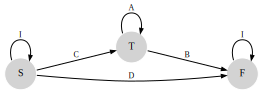

In [6]:
from matrixproducts import fsm_singular
fsm_singular()

Suppressing the inputs $I$ ("applying identity operator") on states 0 and 2 this finite-state machine writes out as the following Hamiltonian

$$
H = \sum_i \left(D_i + C_i B_{i+1} + C_iA_{i+1}B_{i+2} + C_iA_{i+1}A_{i+2}B_{i+3} + \cdots\right).
$$

We can use this finite-state machine as starting point to express any other kind of local Hamiltonian. 

# Matrix Product Diagram

An alternative useful representation to the finite-state machine are matrix product diagrams (MPD). For two sites, the above FSM as MPD transforms to

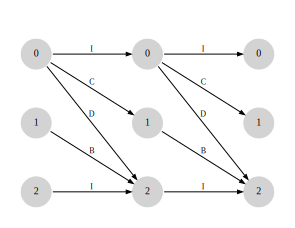

In [7]:
from matrixproducts import mpd_nn
mpd_nn()


which correspond to the MPO

$$
W_i^{\sigma_i^\prime,\sigma_i^{\,}} =
\begin{pmatrix}
    I & C & D \\
    0 & 0 & B \\
    0 & 0 & I
\end{pmatrix}_{(i)}.
$$

and a Hamiltonian

$$
H = \sum_i \left(D_i + C_i B_{i+1}\right)
$$

The input $A$ ("applying operator $A$") does not occur here. This is due to $A$ is only acting as intermediate operator, aka only occurs in Hamiltonians with interactions beyond nearest neighbor. The MPD of the original MPO with next-nearest neighbor interactions is given by

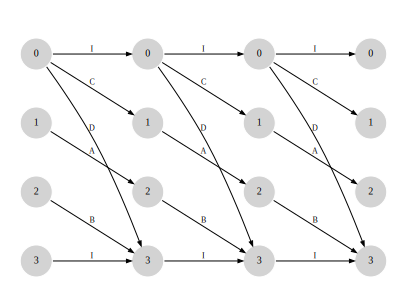

In [8]:
from matrixproducts import mpd_nnn
mpd_nnn()

and has the Hamiltonian representation

$$
H = \sum_i \left(D_i + C_i B_{i+1} + C_iA_{i+1}B_{i+2}\right)
$$

## Tensor Networks

### Algorithms

#### Static

#### Dynamics

## Examples

---

We mimic the system here to have periodic boundary conditions by forming a ring, i.e. the almost right-hand side is connected by the almost left-hand side. This allows us to neglect any boundary effects in our matrix product description here for now.

In [11]:
from graphviz import Digraph

sites = 8
transitions = sites + 1
channels = 3

# graph
graph = Digraph(
        graph_attr={
            'rankdir':'LR',
            'splines':'false',
            'color':'transparent',
            'ranksep':'1'
        },
        node_attr={
            'style':'filled',
            'color':'white',
            'shape':'circle',
            'height':'0.1',
            'fillcolor':'lightgray',
            'fontsize':'10'
        },
        edge_attr={
            'arrowsize':'0.5'
        }
    )

# nodes
prefix = {0: 'a', 1: 'b', 2: 'c'}
with graph.subgraph(name='cluster_I') as child:
    for i in range(transitions):
        child.node(name='I' + str(i), label='0')

for j in range(channels):
    with graph.subgraph(name='cluster_' + prefix[j]) as child:
        for i in range(transitions):
            child.node(name=prefix[j] + str(i), label=str(j+1))

with graph.subgraph(name='cluster_F') as child:
    for i in range(transitions):
        child.node(name='F' + str(i), label=str(channels + 1))

# edges
graph.edges([('I' + str(i),'I' + str(i+1)) for i in range(transitions-1)])
for i in range(transitions):
    graph.edge('I' + str(i), 'a' + str(i), style='invis')
    graph.edge('a' + str(i), 'b' + str(i), style='invis')
    graph.edge('b' + str(i), 'c' + str(i), style='invis')
    graph.edge('c' + str(i), 'F' + str(i), style='invis')
graph.edges([('F' + str(i),'F' + str(i+1)) for i in range(transitions-1)])

#graph.edges()
for i in range(transitions-1):
    # graph.edge('I' + str(i), 'I' + str(i+1))
    graph.edge('I' + str(i), 'a' + str(i+1))
    graph.edge('I' + str(i), 'b' + str(i+1), style='invis')
    graph.edge('I' + str(i), 'c' + str(i+1))
    graph.edge('I' + str(i), 'F' + str(i+1))
    graph.edge('a' + str(i), 'I' + str(i+1), style='invis')
    graph.edge('a' + str(i), 'a' + str(i+1), style='invis')
    graph.edge('a' + str(i), 'b' + str(i+1))
    graph.edge('a' + str(i), 'c' + str(i+1), style='invis')
    graph.edge('a' + str(i), 'F' + str(i+1), style='invis')
    graph.edge('b' + str(i), 'I' + str(i+1), style='invis')
    graph.edge('b' + str(i), 'a' + str(i+1), style='invis')
    graph.edge('b' + str(i), 'b' + str(i+1), style='invis')
    graph.edge('b' + str(i), 'c' + str(i+1), style='invis')
    graph.edge('b' + str(i), 'F' + str(i+1))
    graph.edge('c' + str(i), 'I' + str(i+1), style='invis')
    graph.edge('c' + str(i), 'a' + str(i+1), style='invis')
    graph.edge('c' + str(i), 'b' + str(i+1), style='invis')
    graph.edge('c' + str(i), 'c' + str(i+1), style='invis')
    graph.edge('c' + str(i), 'F' + str(i+1))
    graph.edge('F' + str(i), 'I' + str(i+1), style='invis')
    graph.edge('F' + str(i), 'a' + str(i+1), style='invis')
    graph.edge('F' + str(i), 'b' + str(i+1), style='invis')
    graph.edge('F' + str(i), 'c' + str(i+1), style='invis')
    # graph.edge('F' + str(i), 'F' + str(i+1))

The matrix product diagram for the system here is

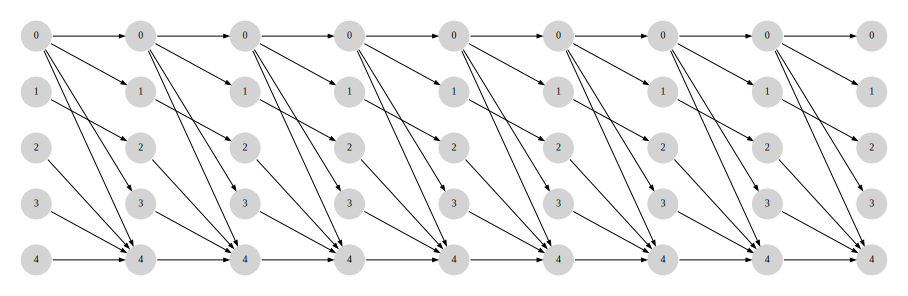

In [12]:
graph

The matrix product operators are $5 \times 5$ matrices which are taking the form

$$
W_i^{\sigma_i^\prime,\sigma_i^{\,}} =
\begin{pmatrix}
I_{00} & c_{01} & c_{02} & c_{03} & d_{44} \\
0      & a_{11} & a_{12} & a_{13} & b_{14} \\
0      & 0      & a_{22} & a_{23} & b_{24} \\
0      & 0      & 0      & a_{33} & b_{34} \\
0      & 0      & 0      & 0      & I_{44}
\end{pmatrix}_{(i)}.
$$

The entries of this matrices corresponding to the edges of the matrix product diagram above, whereby the indices are given by the nodes, though

$$
\begin{align}
C &=
\begin{pmatrix}
c_{01} & c_{02} & c_{03}
\end{pmatrix}
=
\begin{pmatrix}
c & 0 & b
\end{pmatrix}
\\
D &= d_{44} = a \\
A &=
\begin{pmatrix}
a_{11} & a_{12} & a_{13} \\
0      & a_{22} & a_{23} \\
0      & 0      & a_{33} \\
\end{pmatrix}
=
\begin{pmatrix}
0 & I & 0 \\
0 & 0 & 0 \\
0 & 0 & 0 \\
\end{pmatrix} \\
B &=
\begin{pmatrix}
b_{14} \\
b_{24} \\
b_{34}
\end{pmatrix}
=
\begin{pmatrix}
0 \\
c \\
b
\end{pmatrix}
\end{align},
$$

so that the final form is

$$
W_i^{\sigma_i^\prime,\sigma_i^{\,}} =
\begin{pmatrix}
I & c & 0 & b & a \\
0 & 0 & I & 0 & 0 \\
0 & 0 & 0 & 0 & c \\
0 & 0 & 0 & 0 & b \\
0 & 0 & 0 & 0 & I
\end{pmatrix}_{(i)}.
$$

In [13]:
from graphviz import Digraph

FSM = Digraph(
    graph_attr={
        'rankdir':'LR',
        'splines':'true',
        'color':'transparent',
        'ranksep':'1'
    },
    node_attr={
        'style':'filled',
        'color':'white',
        'shape':'circle',
        'height':'0.1',
        'fillcolor':'lightgray',
        'fontsize':'10'
    },
    edge_attr={
        'arrowsize':'0.5'
    }
)

FSM.node(name='0', label='0')
FSM.node(name='1', label='1')
FSM.node(name='2', label='2')
FSM.node(name='3', label='3')
FSM.node(name='4', label='4')

FSM.edge('0','0', label='I')
FSM.edge('0','1', label='c')
FSM.edge('0','3', label='b')
FSM.edge('0','4', label='a')
FSM.edge('1','2', label='I')
FSM.edge('2','4', label='c')
FSM.edge('3','4', label='b')
FSM.edge('4','4', label='I')

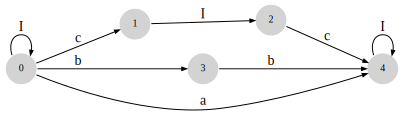

In [14]:
FSM

$$
W_i^{\sigma_i^\prime,\sigma_i^{\,}} =
\begin{array}{ c||c|c|c } 

   & 0 & 1 & 2 & 3 & 4 \\ \hline\hline
 0 & I & c & 0 & b & a \\ \hline
 1 & 0 & 0 & I & 0 & 0 \\ \hline
 2 & 0 & 0 & 0 & 0 & c \\ \hline
 3 & 0 & 0 & 0 & 0 & b \\ \hline
 4 & 0 & 0 & 0 & 0 & I \\
\end{array}
$$

In [15]:
import numpy as np
import sympy as sp

# Define the symbolic operators
A = sp.Symbol('A')
B = sp.Symbol('B')
C = sp.Symbol('C')

# Create a list of local operator matrices
local_operators = [np.array([[1, 0], [0, A]]),
                   np.array([[B, 0], [0, C]])]

# Define the connectivity pattern of the MPO
connectivity = np.array([[1, 0],
                         [1, 1]])

# Initialize the MPO tensor
num_sites = len(local_operators)
num_states = local_operators[0].shape[0]
mpo_tensor = np.zeros((num_sites, num_sites, num_states, num_states))

# Construct the MPO tensor
for i in range(num_sites):
    for j in range(num_sites):
        if connectivity[i, j] == 1:
            mpo_tensor[i, j] = np.matmul(local_operators[i], mpo_tensor[i, j])

# Print the MPO tensor
print(mpo_tensor)


[[[[0. 0.]
   [0. 0.]]

  [[0. 0.]
   [0. 0.]]]


 [[[0. 0.]
   [0. 0.]]

  [[0. 0.]
   [0. 0.]]]]
